In [1]:
%pip install numpy pandas matplotlib scipy qpsolvers osqp cvxopt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import standard libraries
import os
import sys
import timeit
from typing import Optional

# Import third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import qpsolvers

# Import local modules
cwd = os.getcwd()

if os.path.basename(cwd) == "assignments":
    project_root = os.path.dirname(cwd)
else:
    project_root = cwd

src_path = os.path.join(project_root, "src")

if project_root not in sys.path:
    sys.path.append(project_root)
if src_path not in sys.path:
    sys.path.append(src_path)

from estimation.covariance import Covariance, is_pos_def, make_pos_def
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization import Optimization, Objective
from optimization.optimization_data import OptimizationData
from optimization.quadratic_program import QuadraticProgram, USABLE_SOLVERS
from helper_functions import simulate_correlated_gbm

In [3]:
# Set the dimensions
T = 1000       # Number of time steps
N = 50         # Number of assets
rnd_seed = 42  # Random seed for reproducibility

# Set random seed for reproducibility
np.random.seed(rnd_seed)

# Generate a random mean vector
mu = np.random.uniform(0.02, 0.15, size=N)

# Generate a positive definite covariance matrix
eigenvalues = np.random.uniform(0.05, 0.30, size=N)
Lambda = np.diag(eigenvalues)

H = np.random.randn(N, N)
Q, _ = np.linalg.qr(H)

sigma = Q @ Lambda @ Q.T

# Rescale to a correlation matrix with random volatilities
std_devs = np.sqrt(np.diag(sigma))
corr_matrix = sigma / np.outer(std_devs, std_devs)

vols = np.random.uniform(0.10, 0.30, size=N)
sigma = np.diag(vols) @ corr_matrix @ np.diag(vols)

# Check if the covariance matrix is positive definite
print("Is sigma positive definite?", is_pos_def(sigma))

# Generate correlated geometric Brownian motion paths and compute discrete returns
prices = simulate_correlated_gbm(mu=mu, sigma=sigma, T=T, random_seed=None)
returns = prices.pct_change().dropna()

# Compute the vector of expected returns
q = ExpectedReturn().estimate(returns, inplace=False)

# Compute the covariance matrix
P = Covariance().estimate(returns, inplace=False)

# Display the results
print("Vector of expected returns (q):")
print(q)

print("\nCovariance matrix (P):")
print(P)

Is sigma positive definite? True
Vector of expected returns (q):
Asset_1     0.000112
Asset_2     0.000227
Asset_3     0.000453
Asset_4    -0.000029
Asset_5    -0.000142
Asset_6    -0.000068
Asset_7     0.000048
Asset_8     0.000486
Asset_9     0.000067
Asset_10   -0.000092
Asset_11   -0.000166
Asset_12    0.000118
Asset_13    0.000318
Asset_14   -0.000016
Asset_15    0.000278
Asset_16   -0.000292
Asset_17    0.000084
Asset_18   -0.000083
Asset_19   -0.000122
Asset_20    0.000159
Asset_21    0.000224
Asset_22   -0.000109
Asset_23    0.000128
Asset_24    0.000133
Asset_25   -0.000034
Asset_26    0.000261
Asset_27   -0.000305
Asset_28   -0.000021
Asset_29   -0.000008
Asset_30    0.000058
Asset_31    0.000174
Asset_32    0.000057
Asset_33    0.000236
Asset_34    0.000499
Asset_35   -0.000078
Asset_36    0.000068
Asset_37    0.000246
Asset_38    0.000097
Asset_39    0.000026
Asset_40    0.000119
Asset_41   -0.000071
Asset_42    0.000153
Asset_43    0.000012
Asset_44   -0.000015
Asset_45   

In [4]:
# Instantiate the Constraints class
constraints = Constraints(ids=returns.columns.tolist())

# Add budget constraint
constraints.add_budget(rhs=1, sense='=')

# Add box constraints
constraints.add_box(lower=0, upper=0.2)

# Add linear constraints
G = pd.DataFrame(np.zeros((3, N)), columns=constraints.ids)
G.iloc[0, 0:15] = 1
G.iloc[1, 15:45] = 1
G.iloc[2, 40:50] = 1

h = pd.Series([0.3, 0.4, 0.5])
constraints.add_linear(G=G, sense='<=', rhs=h)

# Display selected columns for verification
constraints.linear['G'][['Asset_1', 'Asset_15', 'Asset_16', 'Asset_40', 'Asset_41', 'Asset_50']]

,Asset_1,Asset_15,Asset_16,Asset_40,Asset_41,Asset_50
0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,1.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,1.0


In [5]:
import qpsolvers

print(qpsolvers.available_solvers)

['clarabel', 'cvxopt', 'daqp', 'ecos', 'highs', 'jaxopt_osqp', 'osqp', 'piqp', 'qpalm', 'qpax', 'quadprog', 'scs', 'sip']


In [6]:
# Extract constraints in solver form
GhAb = constraints.to_GhAb()

# Result template for failed solvers
result_on_fail = {
    'solution_found': False,
    'objective': np.nan,
    'primal_residual': np.nan,
    'dual_residual': np.nan,
    'duality_gap': np.nan,
    'runtime': np.nan,
}

# Mean-variance scaling
risk_aversion = 1

# Solvers that were installed / tested
solvers_to_test = ['cvxopt', 'osqp', 'quadprog', 'daqp', 'qtqp']
results = {}

for solver in solvers_to_test:
    try:
        qp = QuadraticProgram(
            P=P.to_numpy() * risk_aversion,
            q=-q.to_numpy(),
            G=GhAb['G'],
            h=GhAb['h'],
            A=GhAb['A'],
            b=GhAb['b'],
            lb=constraints.box['lower'].to_numpy(),
            ub=constraints.box['upper'].to_numpy(),
            solver=solver,
        )

        start = timeit.default_timer()
        qp.solve()
        runtime = timeit.default_timer() - start

        solution = qp.results.get('solution')
        found = getattr(solution, 'found', False)

        gap = np.nan
        if found:
            gap = solution.duality_gap()
            if isinstance(gap, (list, tuple, np.ndarray)):
                gap = gap[0]

        results[solver] = {
            'solution_found': found,
            'objective': qp.objective_value() if found else np.nan,
            'primal_residual': solution.primal_residual() if found else np.nan,
            'dual_residual': solution.dual_residual() if found else np.nan,
            'duality_gap': gap if found else np.nan,
            'runtime': runtime,
        }

    except Exception:
        results[solver] = result_on_fail.copy()

# qpalm crashed the kernel in testing, so record it as failed
results['qpalm'] = result_on_fail.copy()

# Final comparison table: solvers as columns, metrics as rows
results_df = pd.DataFrame(results)
print("Solver comparison:")
display(results_df)

Solver comparison:


,cvxopt,osqp,quadprog,daqp,qtqp,qpalm
solution_found,True,True,True,True,False,False
objective,-0.000306,-0.000304,-0.000306,-0.000306,NaN,NaN
primal_residual,0.0,0.000351,0.0,0.0,NaN,NaN
dual_residual,0.0,0.000004,0.0,0.0,NaN,NaN
duality_gap,0.0,0.000002,0.0,0.0,NaN,NaN
runtime,0.094657,0.003375,0.000541,0.001005,NaN,NaN


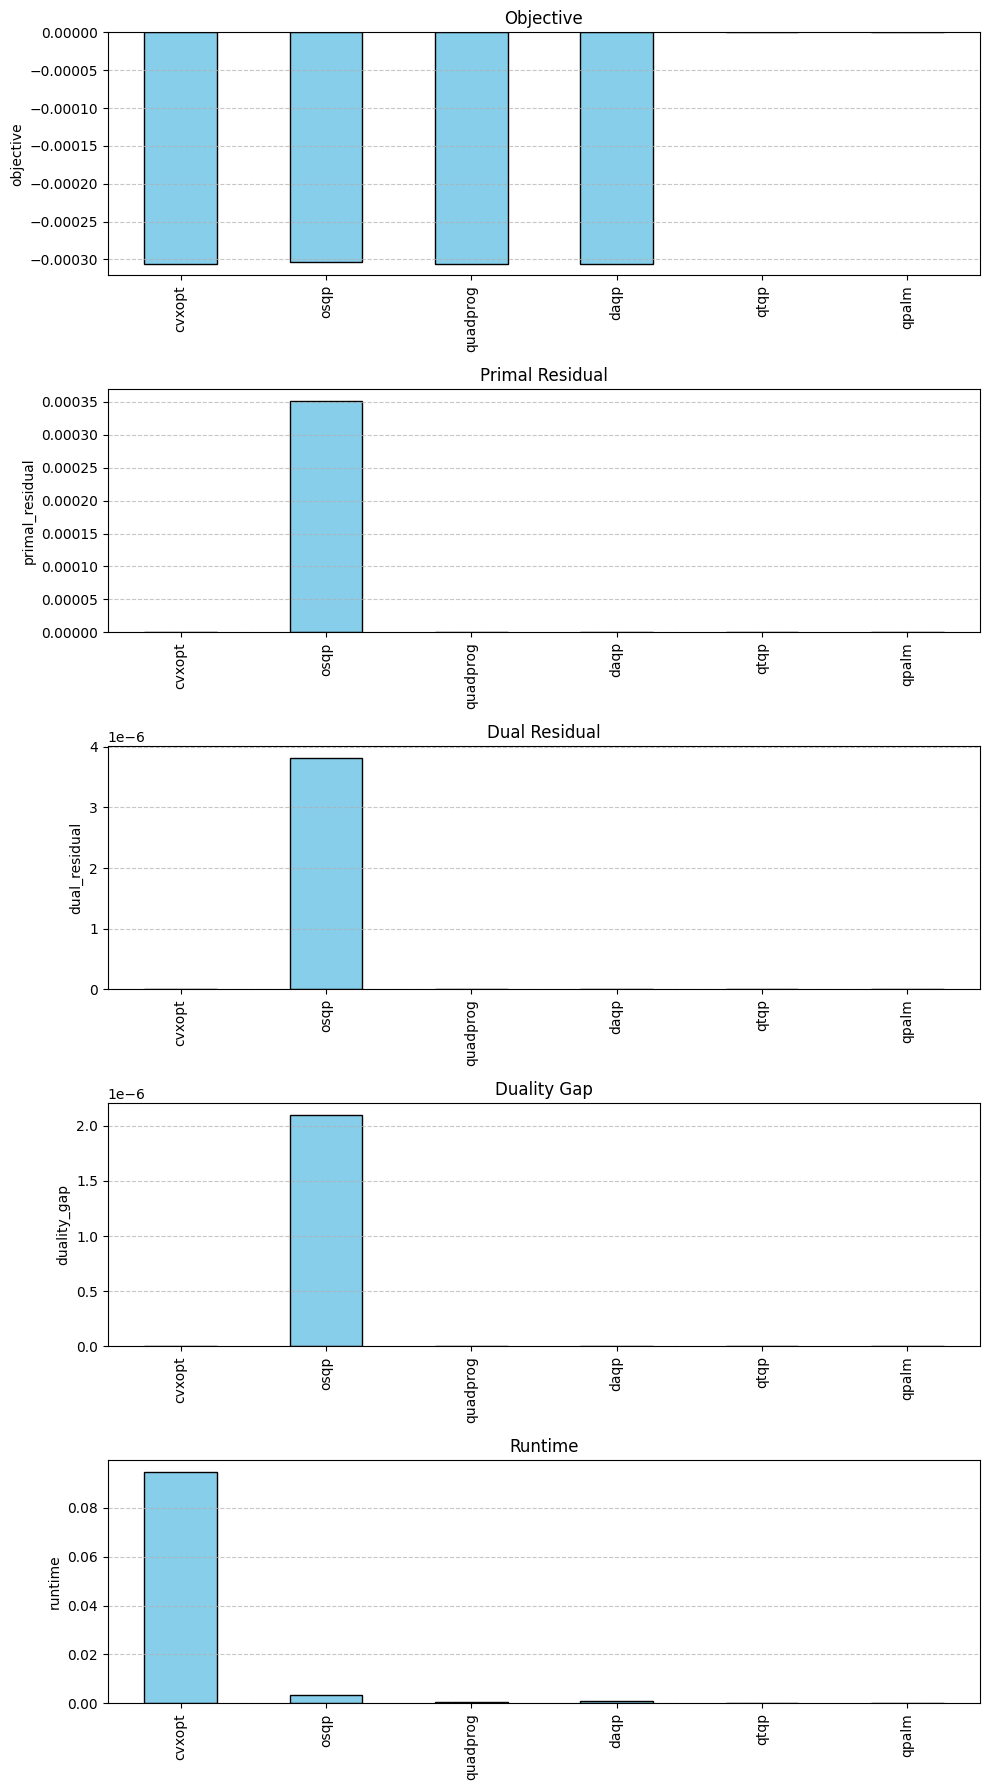

In [7]:
# Visualize numeric metrics
metrics_to_plot = ['objective', 'primal_residual', 'dual_residual', 'duality_gap', 'runtime']
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(10, 18))

for ax, metric in zip(axes, metrics_to_plot):
    values = results_df.loc[metric]
    values.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_ylabel(metric)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Appendix 1.c)

Successful solvers: ['cvxopt', 'osqp', 'quadprog', 'daqp']


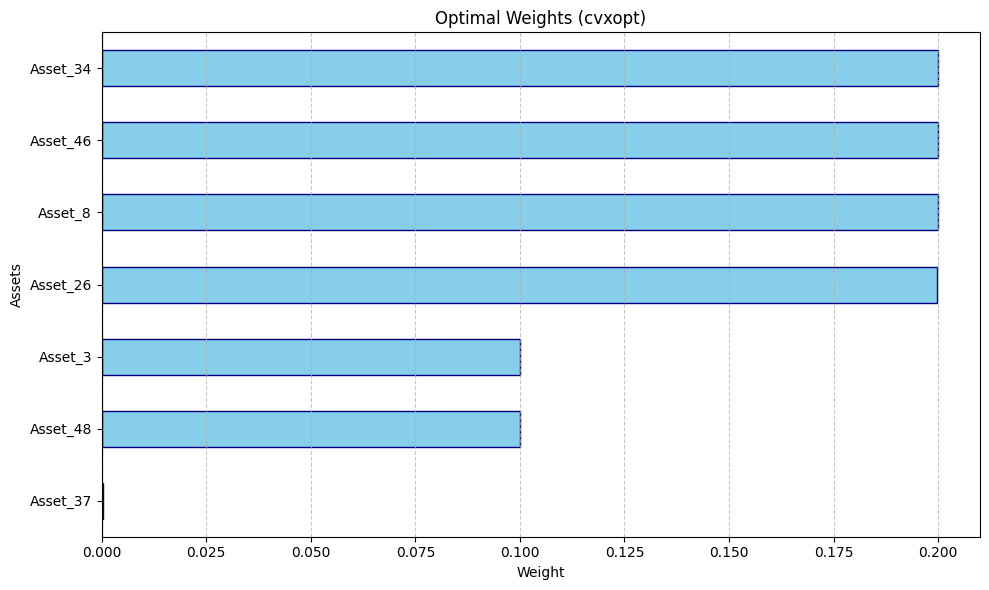

Top 5 holdings for cvxopt:
Asset_34    0.200000
Asset_46    0.199998
Asset_8     0.199991
Asset_26    0.199720
Asset_3     0.100005
Name: cvxopt, dtype: float64



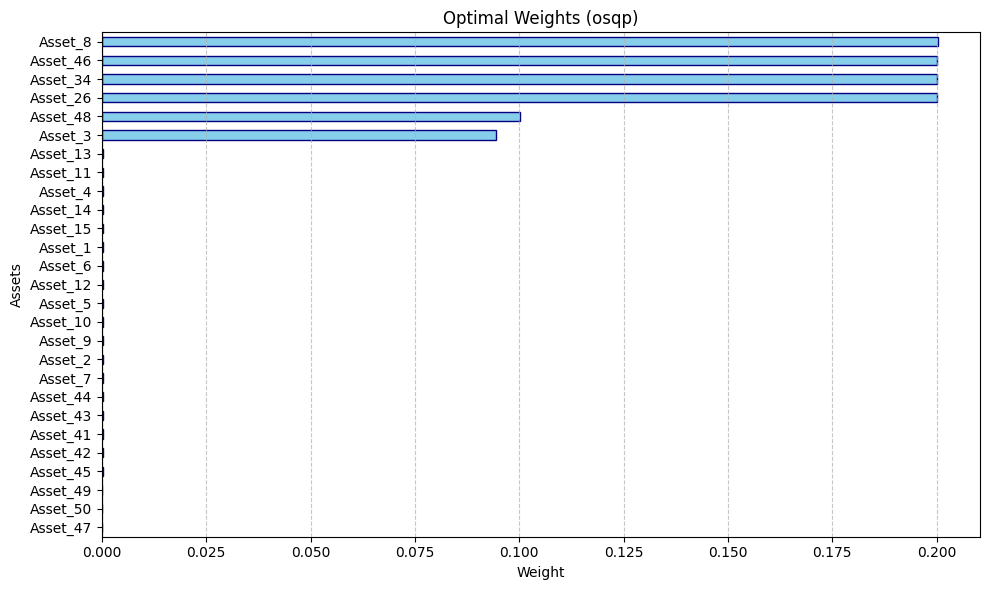

Top 5 holdings for osqp:
Asset_8     0.200351
Asset_46    0.200122
Asset_34    0.199987
Asset_26    0.199963
Asset_48    0.100063
Name: osqp, dtype: float64



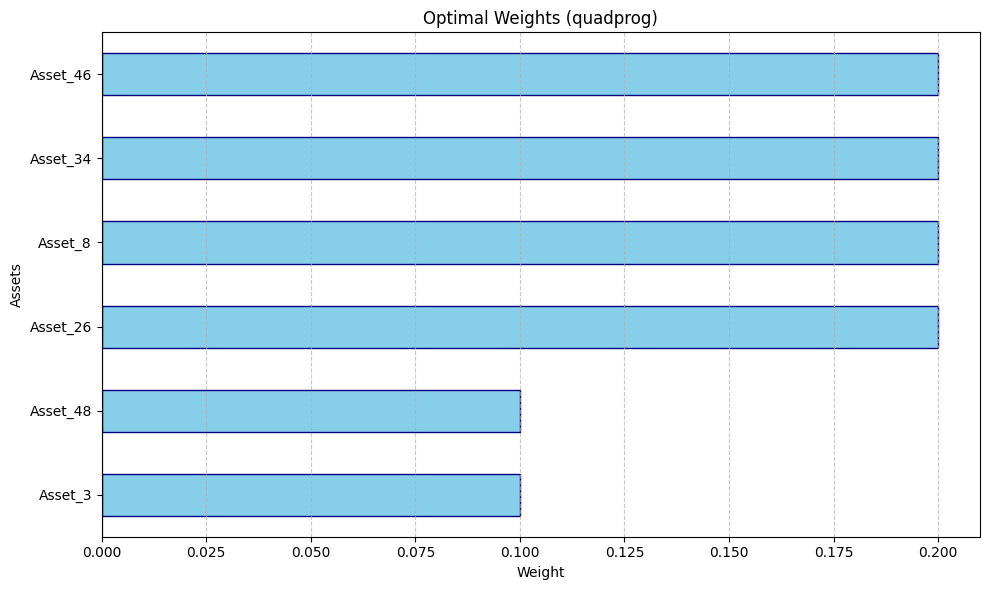

Top 5 holdings for quadprog:
Asset_46    0.2
Asset_34    0.2
Asset_8     0.2
Asset_26    0.2
Asset_48    0.1
Name: quadprog, dtype: float64



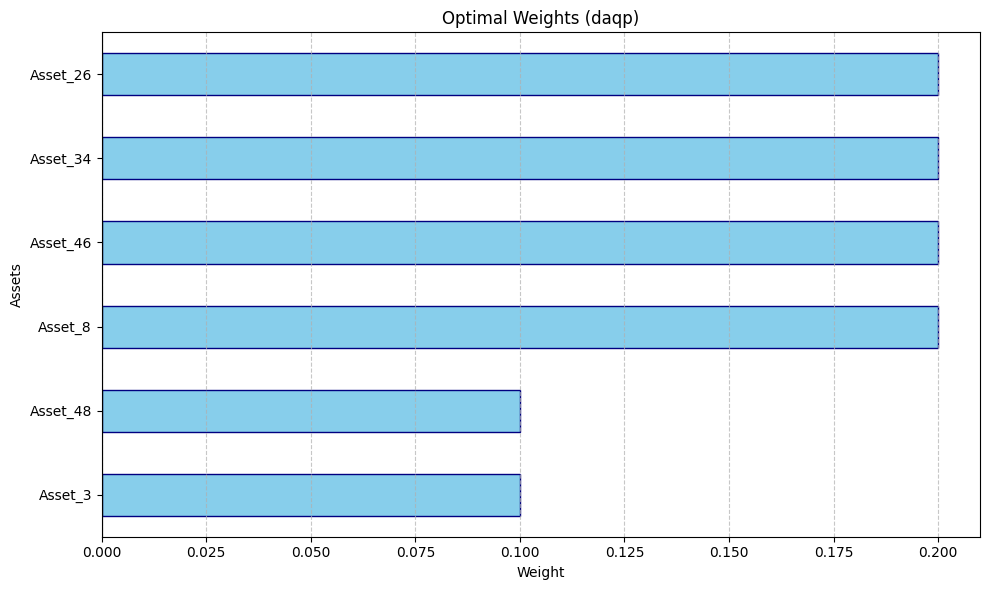

Top 5 holdings for daqp:
Asset_26    0.2
Asset_34    0.2
Asset_46    0.2
Asset_8     0.2
Asset_48    0.1
Name: daqp, dtype: float64



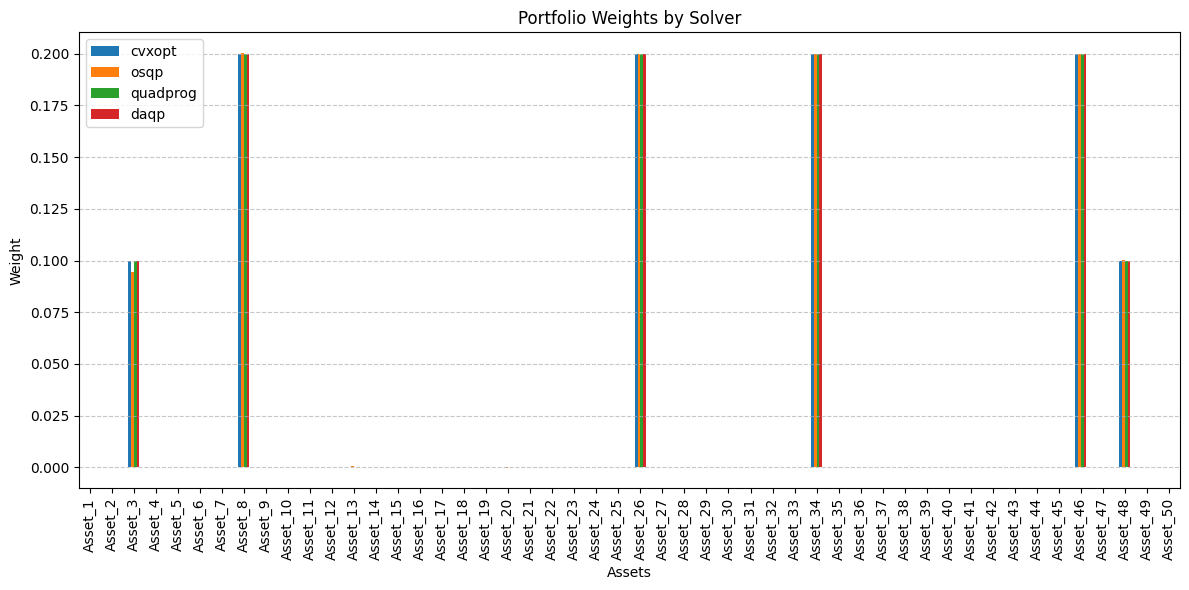

In [8]:
# Appendix: visualize portfolio weights for successful solvers

solvers_to_plot = ['cvxopt', 'osqp', 'quadprog', 'daqp', 'qtqp']
successful_solvers = [
    s for s in solvers_to_plot
    if s in results_df.columns and bool(results_df.loc['solution_found', s])
]

print("Successful solvers:", successful_solvers)

weights_by_solver = {}

for solver_to_plot in successful_solvers:
    qp_plot = QuadraticProgram(
        P=P.to_numpy() * risk_aversion,
        q=-q.to_numpy(),
        G=GhAb['G'],
        h=GhAb['h'],
        A=GhAb['A'],
        b=GhAb['b'],
        lb=constraints.box['lower'].to_numpy(),
        ub=constraints.box['upper'].to_numpy(),
        solver=solver_to_plot,
    )

    qp_plot.solve()
    solution_plot = qp_plot.results.get('solution')

    weights = pd.Series(solution_plot.x, index=returns.columns, name=solver_to_plot)
    weights_by_solver[solver_to_plot] = weights

    weights_filtered = weights[weights.abs() > 1e-4]

    plt.figure(figsize=(10, 6))
    weights_filtered.sort_values().plot(
        kind='barh',
        color='skyblue',
        edgecolor='navy'
    )
    plt.title(f'Optimal Weights ({solver_to_plot})')
    plt.xlabel('Weight')
    plt.ylabel('Assets')
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print(f"Top 5 holdings for {solver_to_plot}:")
    print(weights.sort_values(ascending=False).head(5))
    print()

# Combined weight comparison
if weights_by_solver:
    weights_compare_df = pd.DataFrame(weights_by_solver)

    plt.figure(figsize=(12, 6))
    weights_compare_df.plot(kind='bar', ax=plt.gca())
    plt.title('Portfolio Weights by Solver')
    plt.xlabel('Assets')
    plt.ylabel('Weight')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [11]:
# Define class MinVariance
class MinVariance(Optimization):

    def __init__(self,
                 constraints: Constraints,
                 covariance: Optional[Covariance] = None,
                 **kwargs):
        super().__init__(
            constraints=constraints,
            **kwargs
        )
        self.covariance = Covariance() if covariance is None else covariance

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        n_assets = covmat.shape[0]

        self.objective = Objective(
            q=np.zeros(n_assets),
            P=covmat * 2,
        )
        return None

    def solve(self) -> None:
        if self.params.get('solver_name') == 'analytical':
            GhAb = self.constraints.to_GhAb()
            A = GhAb['A']
            b = GhAb['b']
            G = GhAb['G']
            h = GhAb['h']

            if G is not None or h is not None:
                raise ValueError("Analytical solution only applies to equality constraints Ax = b.")

            lower = self.constraints.box.get('lower')
            upper = self.constraints.box.get('upper')
            if lower is not None or upper is not None:
                lower_np = None if lower is None else np.asarray(lower, dtype=float)
                upper_np = None if upper is None else np.asarray(upper, dtype=float)

                has_finite_lower = lower_np is not None and np.isfinite(lower_np).any()
                has_finite_upper = upper_np is not None and np.isfinite(upper_np).any()

                if has_finite_lower or has_finite_upper:
                    raise ValueError("Analytical solution only applies to equality constraints Ax = b.")

            if A is None or b is None:
                raise ValueError("Analytical minimum-variance solution requires equality constraints Ax = b.")

            P = self.objective.coefficients['P']
            Sigma = np.asarray(P, dtype=float) / 2.0
            A = np.asarray(A, dtype=float)
            b = np.asarray(b, dtype=float).reshape(-1, 1)

            if not is_pos_def(Sigma):
                raise ValueError("Analytical solution requires Sigma to be positive definite.")

            Sigma_inv = np.linalg.inv(Sigma)
            middle = A @ Sigma_inv @ A.T

            if np.linalg.matrix_rank(middle) < middle.shape[0]:
                raise ValueError("Analytical solution requires A Sigma^{-1} A^T to be invertible.")

            middle_inv = np.linalg.inv(middle)
            x_star = Sigma_inv @ A.T @ middle_inv @ b
            x_star = x_star.flatten()

            self.results = {
                'weights': x_star,
                'status': True,
                'solver': 'analytical'
            }
            return None

        else:
            return super().solve()


# Create a constraints object with just a budget constraint
constraints_mv = Constraints(ids=returns.columns.tolist())
constraints_mv.add_budget(rhs=1, sense='=')

# Instantiate the MinVariance object with analytical solver
minvar = MinVariance(
    constraints=constraints_mv,
    covariance=Covariance(check_positive_definite=True),
    solver_name='analytical'
)

# Create the optimization data
optimization_data = OptimizationData(return_series=returns)

# Solve analytically
minvar.set_objective(optimization_data=optimization_data)
minvar.solve()

weights_minvar = pd.Series(minvar.results['weights'], index=returns.columns, name='Analytical')
print("Analytical minimum-variance weights:")
print(weights_minvar)
print("\nSum of weights:", weights_minvar.sum())

# Solve numerically for comparison
minvar_qp = MinVariance(
    constraints=constraints_mv,
    covariance=Covariance(check_positive_definite=True),
    solver_name='cvxopt'
)

minvar_qp.set_objective(optimization_data=optimization_data)
minvar_qp.solve()

weights_minvar_qp = pd.Series(minvar_qp.results['weights'], index=returns.columns, name='QP (cvxopt)')
print("\nNumerical minimum-variance weights:")
print(weights_minvar_qp)
print("\nSum of weights:", weights_minvar_qp.sum())

# Compare both solutions
comparison_df = pd.DataFrame({
    'Analytical': weights_minvar,
    'QP (cvxopt)': weights_minvar_qp
})

# Compute objective values
obj_analytical = 0.5 * weights_minvar.to_numpy() @ minvar.objective.coefficients['P'] @ weights_minvar.to_numpy()
obj_qp = 0.5 * weights_minvar_qp.to_numpy() @ minvar_qp.objective.coefficients['P'] @ weights_minvar_qp.to_numpy()

print("Objective value (Analytical):", obj_analytical)
print("Objective value (QP):", obj_qp)

print("\nComparison of analytical and numerical solutions:")
print(comparison_df)

Analytical minimum-variance weights:
Asset_1     0.004001
Asset_2     0.012058
Asset_3     0.038712
Asset_4     0.075012
Asset_5     0.023790
Asset_6    -0.004303
Asset_7     0.006397
Asset_8     0.008923
Asset_9    -0.002294
Asset_10    0.014340
Asset_11    0.008019
Asset_12    0.008548
Asset_13    0.017138
Asset_14    0.009928
Asset_15   -0.001887
Asset_16    0.016335
Asset_17    0.036146
Asset_18    0.034152
Asset_19    0.029072
Asset_20    0.008207
Asset_21    0.016694
Asset_22    0.022691
Asset_23    0.073971
Asset_24   -0.001732
Asset_25    0.017848
Asset_26   -0.009655
Asset_27   -0.001180
Asset_28    0.097097
Asset_29    0.004808
Asset_30    0.062156
Asset_31    0.023553
Asset_32    0.011919
Asset_33    0.039555
Asset_34    0.010168
Asset_35    0.025415
Asset_36    0.040932
Asset_37    0.013188
Asset_38    0.020456
Asset_39    0.002303
Asset_40    0.008778
Asset_41   -0.001705
Asset_42   -0.001205
Asset_43   -0.002734
Asset_44    0.012455
Asset_45    0.013849
Asset_46    0.0528

### Appendix for 2.)


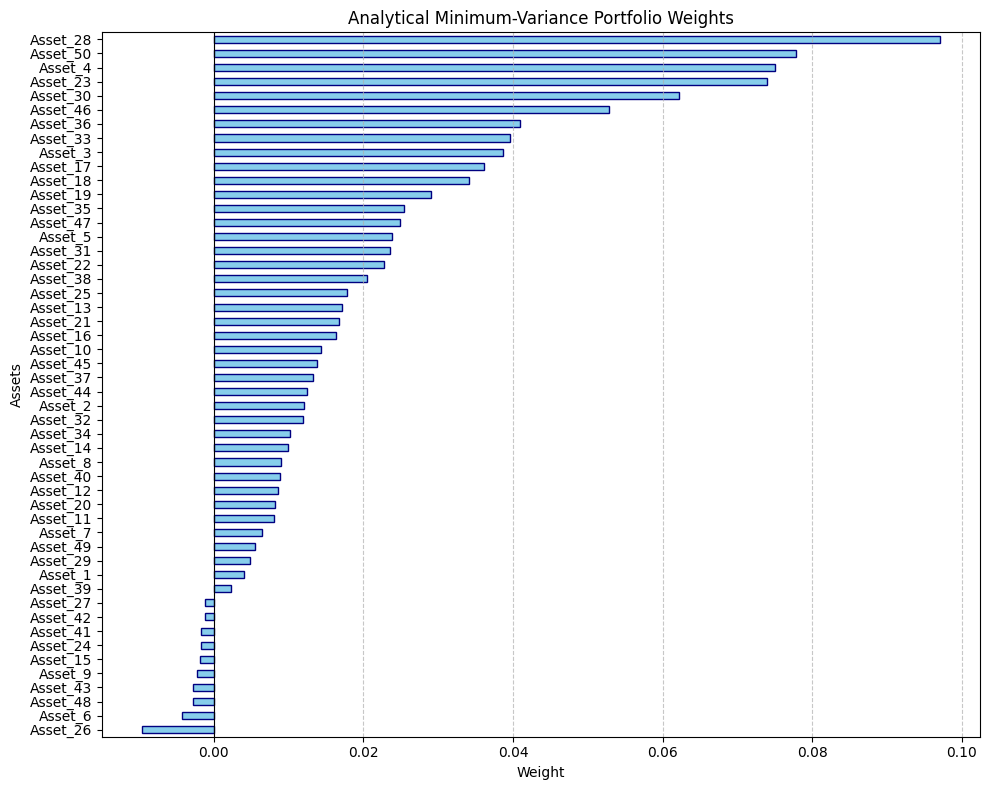

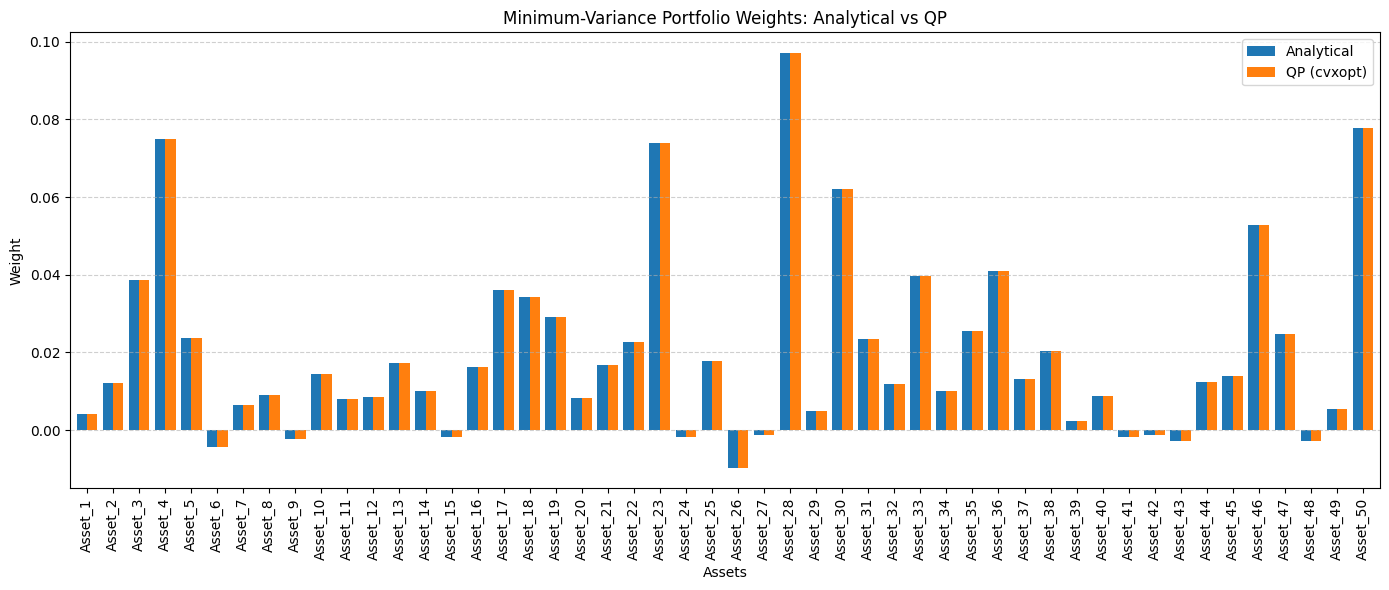

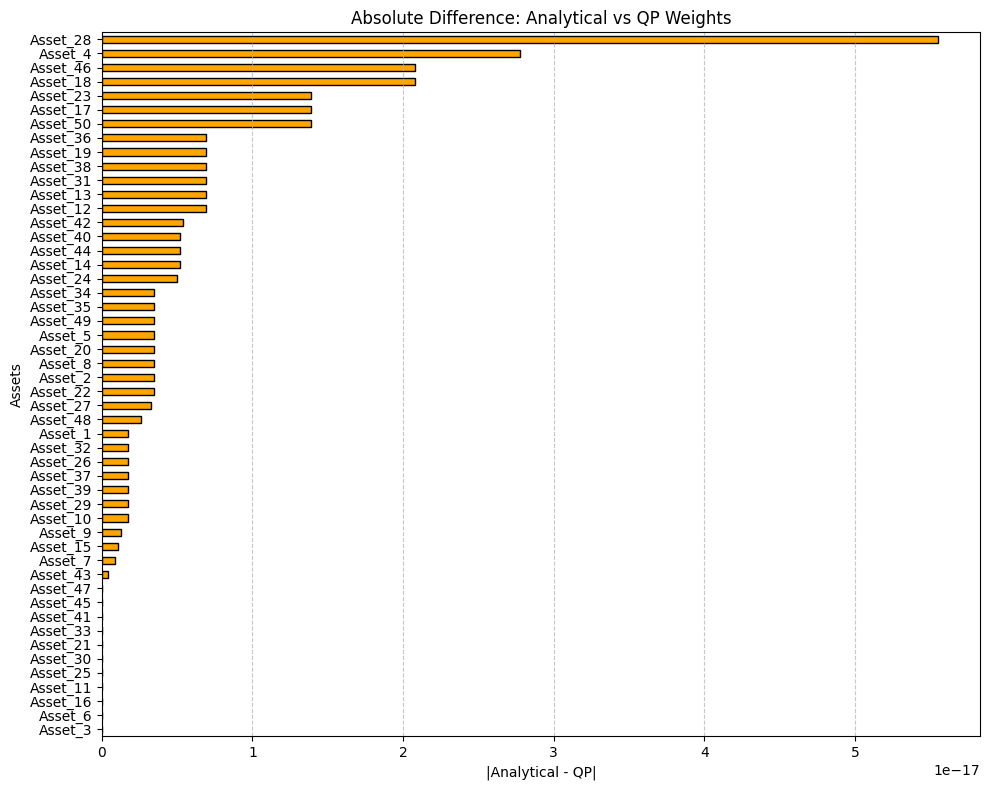

In [12]:
# Appendix: visualization of analytical vs numerical minimum-variance solution

comparison_df = pd.DataFrame({
    'Analytical': weights_minvar,
    'QP (cvxopt)': weights_minvar_qp
})

# Plot 1: analytical weights
plt.figure(figsize=(10, 8))
weights_minvar.sort_values().plot(
    kind='barh',
    color='skyblue',
    edgecolor='navy'
)
plt.title('Analytical Minimum-Variance Portfolio Weights')
plt.xlabel('Weight')
plt.ylabel('Assets')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 2: analytical vs numerical comparison
plt.figure(figsize=(14, 6))
comparison_df.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Minimum-Variance Portfolio Weights: Analytical vs QP')
plt.xlabel('Assets')
plt.ylabel('Weight')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot 3: absolute differences
weight_diff = (weights_minvar - weights_minvar_qp).abs()

plt.figure(figsize=(10, 8))
weight_diff.sort_values().plot(
    kind='barh',
    color='orange',
    edgecolor='black'
)
plt.title('Absolute Difference: Analytical vs QP Weights')
plt.xlabel('|Analytical - QP|')
plt.ylabel('Assets')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

